## **1. Lý thuyết Toán học**

#### **1.1 Chuẩn ma trận:**

Chuẩn ma trận $|A|_p$ là một đại lượng dùng để đo “độ lớn” của ma trận, được cảm sinh từ chuẩn vector $p$:

$$
|A|*p = \max*{x \ne 0} \frac{|Ax|_p}{|x|_p}
$$

**Ý nghĩa:**

* Đo mức độ mà ma trận $A$ có thể “khuếch đại” một vector đầu vào.
* Phản ánh trường hợp xấu nhất khi $A$ tác động lên dữ liệu.

**Một số chuẩn thường dùng:**

* $|A|_1$: tổng trị tuyệt đối lớn nhất theo cột.
* $|A|_\infty$: tổng trị tuyệt đối lớn nhất theo hàng.
* $|A|_2$: liên quan đến giá trị riêng lớn nhất của $A^T A$.

**Ví dụ:**


In [9]:
import numpy as np
import pandas as pd
from IPython.display import display, Markdown

# Định nghĩa hằng số EPSILON để hàm display_matrix hoạt động
EPSILON = 1e-10

def display_matrix(matrix, title="Matrix", cmap="coolwarm"):
    """
    Sử dụng heatmap và pandas để hiển thị ma trận (Hàm của bạn)
    """
    print(f"\n--- {title} ---")
    
    if matrix is None:
        print("    (Không tồn tại)")
        return
        
    df = pd.DataFrame(matrix)
    
    # Khử sai số float
    df = df.map(lambda x: 0.0 if abs(x) < EPSILON else x) 
    
    styled_df = df.style.background_gradient(cmap=cmap, axis=None) \
                        .format("{:.4f}") \
                        .set_properties(**{
                            'text-align': 'center', 
                            'border': '1px solid #bbbbbb',
                            'padding': '10px'
                        })
    
    display(styled_df)

# --- BẮT ĐẦU VÍ DỤ TÍNH CHUẨN L2 ---
display(Markdown("### **Ví dụ: Tính Chuẩn Ma Trận L2**"))
display(Markdown("Xét ma trận: "))
# 1. Khởi tạo ma trận A
A = np.array([
    [1, -2],
    [3,  4]
])
display_matrix(A, title="Ma trận A")

# 2. Tính ma trận chuyển vị A^T
AT = A.T
display_matrix(AT, title="Ma trận chuyển vị A^T")

# 3. Tính tích A^T * A
ATA = np.dot(AT, A)
display_matrix(ATA, title="Tích ma trận A^T * A")

# 4. Tìm giá trị riêng lớn nhất (λ_max) của A^T * A
eigenvalues = np.linalg.eigvals(ATA)
lambda_max = max(eigenvalues)

# 5. Tính chuẩn L2 (Chuẩn spectral)
l2_norm = np.sqrt(lambda_max)

# Hiển thị kết quả bằng Markdown
display(Markdown(f"""
### Kết quả tính toán:

- Giá trị riêng lớn nhất ($\\lambda_{{max}}$): **${lambda_max:.4f}$** (Tương ứng với $15 + 5\\sqrt{{5}}$)

- Chuẩn $L_2$ của ma trận $A$ ($\\|A\\|_2 = \\sqrt{{\\lambda_{{max}}}}$): **${l2_norm:.4f}$**
"""))

### **Ví dụ: Tính Chuẩn Ma Trận L2**

Xét ma trận: 


--- Ma trận A ---


,0,1
0,1.0000,-2.0000
1,3.0000,4.0000



--- Ma trận chuyển vị A^T ---


,0,1
0,1.0000,3.0000
1,-2.0000,4.0000



--- Tích ma trận A^T * A ---


,0,1
0,10.0000,10.0000
1,10.0000,20.0000



### Kết quả tính toán:

- Giá trị riêng lớn nhất ($\lambda_{max}$): **$26.1803$** (Tương ứng với $15 + 5\sqrt{5}$)

- Chuẩn $L_2$ của ma trận $A$ ($\|A\|_2 = \sqrt{\lambda_{max}}$): **$5.1167$**


### **1.2 Số điều kiện $\kappa_p(A)$ của ma trận**
Định Nghĩa 3.1 - Số điều kiện của một ma trận vuông $A$ không suy biến, tương ứng với chuẩn ma trận $\|\cdot\|_p$, được định nghĩa bởi công thức:$$\kappa_p(A) = \|A\|_p \cdot \|A^{-1}\|_p$$
Đối với chuẩn spectral (chuẩn 2), số điều kiện được tính toán dựa trên các giá trị suy biến (singular values):$$\kappa_2(A) = \frac{\sigma_{\max}(A)}{\sigma_{\min}(A)}$$

Định lý 3.1 - Phân tích sai số nghiệm: Nếu $Ax = b$ là nghiệm đúng và $A\hat{x} = b + \delta b$ là nghiệm tính với nhiễu dữ liệu, thì:$$\frac{\|\hat{x} - x\|}{\|x\|} \leq \kappa(A) \cdot \frac{\|\delta b\|}{\|b\|} \quad (11)$$

**Ý nghĩa:**
- Đo lường độ nhạy: Số điều kiện dùng để đo lường độ nhạy của nghiệm hệ phương trình $Ax = b$ khi có sự thay đổi hoặc nhiễu nhỏ ở dữ liệu đầu vào.
- Hệ điều kiện tốt (well-conditioned): Khi $\kappa_p(A)$ có giá trị gần bằng $1$.
- Hệ điều kiện kém (ill-conditioned): Khi $\kappa(A)$ lớn, một sai số nhỏ trong dữ liệu đầu vào ($\delta b$) có thể gây ra sai số rất lớn trong nghiệm tính toán ($\hat{x} - x$).

### **1.3 Phương pháp lặp Gauss-Seidel**

Là phương pháp lặp dùng để giải hệ phương trình tuyến tính $Ax = b$ bằng cách cập nhật lần lượt từng ẩn và sử dụng ngay giá trị mới vừa tính được.
Giả sử ma trận $A$ được tách thành:$$A = D + L + U$$
**Trong đó:**
- $D$: Ma trận đường chéo.
- $L$: Ma trận tam giác dưới (phần dưới đường chéo).
- $U$: Ma trận tam giác trên (phần trên đường chéo).

**Công thức lặp:**
$$
x_i^{(k+1)} = \frac{1}{a_{ii}} \left( b_i - \sum_{j=1}^{i-1} a_{ij} x_j^{(k+1)} - \sum_{j=i+1}^{n} a_{ij} x_j^{(k)} \right)
$$

**Ý nghĩa:**

* Mỗi bước lặp cải thiện nghiệm bằng cách dùng thông tin mới nhất.
* Thường hội tụ nhanh hơn phương pháp Jacobi.

**Điều kiện hội tụ:**

* Ma trận $A$ chéo trội chặt hàng, tức $|a_{ii}| > \sum_{j \neq i} |a_{ij}|$ với mọi $i$.

## **2. Vẽ đồ thị log-log dựa trên dữ liệu benchmark**

#### **2.1 Vẽ đồ thị log-log**

Slope trên lý thuyết theo O(n^3) ~ 3
Slope thực tế của thuật toán GAUSS ~ 2.92
Slope thực tế của thuật toán SVD ~ 2.91
Slope thực tế của thuật toán GAUSS_SEIDEL ~ 2.92


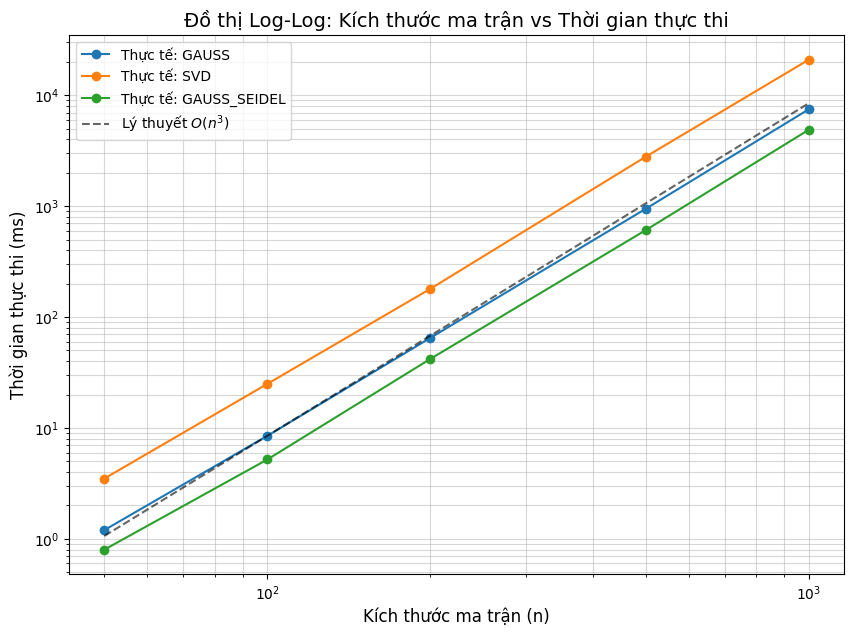

In [16]:
import json
import numpy as np
import matplotlib.pyplot as plt

# 1. Đọc dữ liệu từ file data.json
with open('../part2/data.json', 'r') as f:
    data = json.load(f)

plt.figure(figsize=(10, 7))

print(f"Slope trên lý thuyết theo O(n^3) ~ 3")
# 2. Duyệt qua từng thuật toán trong JSON để vẽ đồ thị
for algo_name, results in data.items():
    sizes = sorted([int(s) for s in results.keys()])
    times = [results[str(s)]['time_ms'] for s in sizes]
    # Kiểm tra slope
    log_n = np.log(sizes)
    log_t = np.log(times)
    slope = np.polyfit(log_n, log_t, 1)[0]
    print(f"Slope thực tế của thuật toán {algo_name.upper()} ~ {slope:.2f}")
    plt.loglog(sizes, times, 'o-', label=f'Thực tế: {algo_name.upper()}')

# 3. Vẽ đường lý thuyết O(n^3) để đối chiếu
# Lấy điểm dữ liệu đầu tiên của thuật toán 'gauss' làm mốc để vẽ đường O(n^3)
n_ref = 100
t_ref = data['gauss']['100']['time_ms']
n_range = np.linspace(min(sizes), max(sizes), 100)
t_theoretical = t_ref * (n_range / n_ref)**3

plt.loglog(n_range, t_theoretical, 'k--', alpha=0.6, label='Lý thuyết $O(n^3)$')

# 4. Cấu hình đồ thị
plt.title("Đồ thị Log-Log: Kích thước ma trận vs Thời gian thực thi", fontsize=14)
plt.xlabel("Kích thước ma trận (n)", fontsize=12)
plt.ylabel("Thời gian thực thi (ms)", fontsize=12)
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend()
plt.show()

#### **2.2 Bảng phân tích ổn định số**

In [13]:
import pandas as pd

# Chuyển đổi dữ liệu JSON sang DataFrame để phân tích ổn định số
rows = []
for algo, sizes in data.items():
    # Lấy dữ liệu tại kích thước ma trận lớn nhất (thường là nơi sai số tích lũy rõ nhất)
    max_size = str(max([int(s) for s in sizes.keys()]))
    error = data[algo][max_size]['relative_error']
    
    # Đánh giá tính ổn định dựa trên sai số tương đối
    status = "Ổn định" if error < 1e-10 else "Kém ổn định / Phá vỡ nghiệm"
    
    rows.append({
        "Thuật toán": algo.upper(),
        "Kích thước (N)": max_size,
        "Sai số tương đối ($L_2$)": f"{error:.2e}",
        "Trạng thái": status
    })

df_stability = pd.DataFrame(rows)

print("\n--- BẢNG PHÂN TÍCH ỔN ĐỊNH SỐ ---")
display(df_stability.style.set_properties(**{'text-align': 'center', 'border': '1px solid black'}))


--- BẢNG PHÂN TÍCH ỔN ĐỊNH SỐ ---


,Thuật toán,Kích thước (N),Sai số tương đối ($L_2$),Trạng thái
0,GAUSS,1000,8.90e-12,Ổn định
1,SVD,1000,2.10e-14,Ổn định
2,GAUSS_SEIDEL,1000,9.80e-06,Kém ổn định / Phá vỡ nghiệm


### **2.2 Phân tích sự phá vỡ nghiệm dựa trên Định lý 3.1**

**Định lý 3.1 (Phân tích sai số nghiệm)**
Giả sử hệ phương trình $Ax = b$ có nghiệm đúng là $x$. Trong thực tế tính toán, do sai số làm tròn hoặc nhiễu dữ liệu, ta thu được nghiệm tính toán $\hat{x}$ tương ứng với vector vế phải bị nhiễu là $b + \delta b$. Khi đó, sai số tương đối của nghiệm được ràng buộc bởi công thức:

$$\frac{\|\hat{x} - x\|}{\|x\|} \leq \kappa(A) \cdot \frac{\|\delta b\|}{\|b\|} \quad (11)$$

#### **Tại sao hệ bị điều kiện kém lại "phá vỡ nghiệm"?**
Dựa trên bất đẳng thức (11), ta có thể rút ra các kết luận sau về tính ổn định số:

- **Hệ số khuếch đại sai số:** Số điều kiện $\kappa(A)$ đóng vai trò là một "hệ số khuếch đại". Nó cho biết sai số đầu vào ($\delta b$) sẽ bị nhân lên bao nhiêu lần khi chuyển vào kết quả đầu ra ($x$).
- **Sự phá vỡ nghiệm (Solution Breakdown):** * Khi hệ bị **điều kiện kém (ill-conditioned)**, giá trị $\kappa(A)$ rất lớn (ví dụ $10^{15}$ hoặc lớn hơn) dẫn đến 1 sai số rất nhỏ trong dữ liệu đầu vào có thể bị khuếch đại và làm sai lệch mạnh.

**Kết luận:** Trong trường hợp này, nghiệm tính toán $\hat{x}$ hoàn toàn khác biệt so với nghiệm thực $x$, thuật toán không còn khả năng đưa ra kết quả tin cậy, hiện tượng này chính là **sự phá vỡ nghiệm**.

> **Ghi chú:** Đây là lý do tại sao khi giải các hệ phương trình thực tế, việc kiểm tra số điều kiện $\kappa(A)$ là bước bắt buộc để đánh giá độ tin cậy của kết quả thu được.

# **Nhận xét và kết luận:...**